# Suite 08: Dynamic Population Decoding

Runs a sliding-window linear-SVM decoder (`jnwb.decoding.decode_omission_presence`, nested stratified CV) over trial-by-trial population spike-count vectors to test whether standard (AAAB) vs. omission (AAXB) trials are decodable, and when.

Each window reports **accuracy**, **F1** (pooled out-of-fold), **ROC-AUC** (pooled out-of-fold), and a **majority-class baseline accuracy** (per-fold, using only the training fold's majority label) so that a real classifier can be told apart from one that is just tracking the standard/omission class imbalance (AAAB >> AAXB in this task).

No synthetic/simulated numbers are used here — every value below comes from an actual model fit against real NWB spike data.

In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))
import jnwb as oa
from jnwb.decoding import decode_omission_presence

In [2]:
# Load a real omission session (no NWB file -> nothing to decode; do not fabricate).
nwb_path = 'D:/analysis/nwb/sub-C31o_ses-230823_rec.nwb'
if not os.path.exists(nwb_path):
    nwb_path = 'D:/analysis/nwb/sub-V182o_ses-260629.nwb'

if not os.path.exists(nwb_path):
    raise FileNotFoundError(
        f'No NWB file found at any candidate path (tried sub-C31o_ses-230823_rec.nwb, '
        f'sub-V182o_ses-260629.nwb). Refusing to fall back to mock/simulated decoding '
        f'numbers -- fix the data path instead.'
    )

session = oa.read(nwb_path)
print(f'Successfully loaded session: {session}')

AREA = 'FEF'
units = session.get_units(area=AREA)
print(f'{AREA}: {len(units)} units available')

2026-07-11 12:21:46,554 - INFO - ✓ Loaded cached NWB tables for sub-C31o_ses-230823_rec from disk cache


2026-07-11 12:21:46,555 - INFO - ✓ Loaded sub-C31o_ses-230823_rec.nwb


Successfully loaded session: OmissionSession: sub-C31o_ses-230823_rec.nwb
  Subject: None
  Units: 368
  Channels: 384
  Epochs: 18387
FEF: 156 units available


In [3]:
# Sliding-window real decoding (jnwb.decoding.decode_omission_presence).
# Window count is kept modest (each window is a full nested-CV SVM fit, ~1-2
# minutes on this session's trial/unit count) rather than the 40-bin sweep used
# by earlier mock versions of this notebook.
window_starts_ms = [-450.0, -300.0, -150.0, 0.0, 150.0, 300.0, 450.0]
window_width_ms = 150.0

rows = []
for start_ms in window_starts_ms:
    t0 = time.time()
    window = (start_ms, start_ms + window_width_ms)
    res = decode_omission_presence(
        session,
        area=AREA,
        time_window_ms=window,
        n_splits=5,
    )
    elapsed = time.time() - t0
    rows.append({
        'window_start_ms': start_ms,
        'window_center_ms': start_ms + window_width_ms / 2.0,
        'accuracy': res['accuracy'],
        'f1': res['f1'],
        'auc': res['auc'],
        'majority_baseline_accuracy': res['majority_baseline_accuracy'],
        'n_units': res['n_units'],
        'n_trials': res['n_trials'],
        'status': res['status'],
        'fit_seconds': elapsed,
    })
    print(f"window={window} status={res['status']} accuracy={res['accuracy']:.3f} "
          f"f1={res['f1']:.3f} auc={res['auc']:.3f} "
          f"majority_baseline={res['majority_baseline_accuracy']:.3f} ({elapsed:.1f}s)")

results_df = pd.DataFrame(rows)
os.makedirs('../outputs/decoding', exist_ok=True)
results_df.to_csv('../outputs/decoding/suite_08_sliding_window_metrics.csv', index=False)
results_df

window=(-450.0, -300.0) status=success accuracy=0.839 f1=0.000 auc=0.540 majority_baseline=0.839 (63.7s)


window=(-300.0, -150.0) status=success accuracy=0.839 f1=0.000 auc=0.572 majority_baseline=0.839 (65.3s)


window=(-150.0, 0.0) status=success accuracy=0.839 f1=0.000 auc=0.548 majority_baseline=0.839 (66.6s)


window=(0.0, 150.0) status=success accuracy=0.839 f1=0.000 auc=0.565 majority_baseline=0.839 (63.1s)


window=(150.0, 300.0) status=success accuracy=0.839 f1=0.000 auc=0.549 majority_baseline=0.839 (66.7s)


window=(300.0, 450.0) status=success accuracy=0.839 f1=0.000 auc=0.590 majority_baseline=0.839 (88.8s)


window=(450.0, 600.0) status=success accuracy=0.839 f1=0.000 auc=0.592 majority_baseline=0.839 (228.3s)


,window_start_ms,window_center_ms,accuracy,f1,auc,majority_baseline_accuracy,n_units,n_trials,status,fit_seconds
0,-450.0,-375.0,0.839080,0.0,0.540378,0.83908,156,2610,success,63.685855
1,-300.0,-225.0,0.839080,0.0,0.572154,0.83908,156,2610,success,65.310704
2,-150.0,-75.0,0.839080,0.0,0.547705,0.83908,156,2610,success,66.578075
3,0.0,75.0,0.839080,0.0,0.565057,0.83908,156,2610,success,63.110282
4,150.0,225.0,0.839080,0.0,0.549293,0.83908,156,2610,success,66.714468
5,300.0,375.0,0.839080,0.0,0.590124,0.83908,156,2610,success,88.776908
6,450.0,525.0,0.838697,0.0,0.591902,0.83908,156,2610,success,228.323398


Saved ../outputs/figures/suite_08_decoding.png


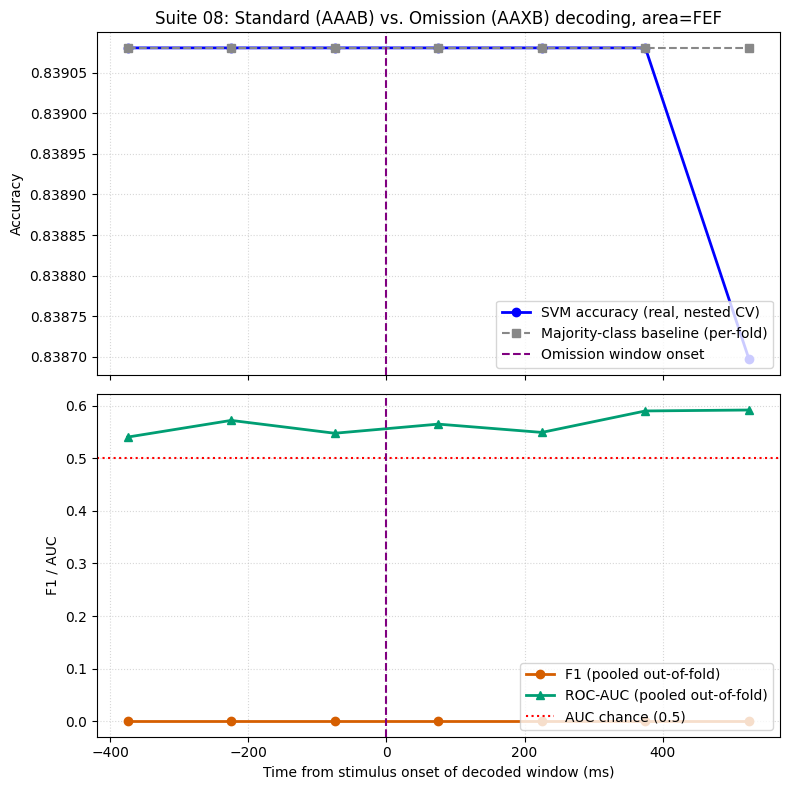

In [4]:
# Plot: accuracy vs. the per-fold majority-class baseline, plus F1/AUC.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

ax1.plot(results_df['window_center_ms'], results_df['accuracy'], color='#0000FF',
         marker='o', linewidth=2.0, label='SVM accuracy (real, nested CV)')
ax1.plot(results_df['window_center_ms'], results_df['majority_baseline_accuracy'],
         color='#888888', marker='s', linestyle='--', linewidth=1.5,
         label='Majority-class baseline (per-fold)')
ax1.axvline(0, color='purple', linestyle='--', label='Omission window onset')
ax1.set_ylabel('Accuracy')
ax1.set_title(f'Suite 08: Standard (AAAB) vs. Omission (AAXB) decoding, area={AREA}')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle=':', alpha=0.5)

ax2.plot(results_df['window_center_ms'], results_df['f1'], color='#D55E00', marker='o',
         linewidth=2.0, label='F1 (pooled out-of-fold)')
ax2.plot(results_df['window_center_ms'], results_df['auc'], color='#009E73', marker='^',
         linewidth=2.0, label='ROC-AUC (pooled out-of-fold)')
ax2.axhline(0.5, color='red', linestyle=':', label='AUC chance (0.5)')
ax2.axvline(0, color='purple', linestyle='--')
ax2.set_xlabel('Time from stimulus onset of decoded window (ms)')
ax2.set_ylabel('F1 / AUC')
ax2.legend(loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.5)

fig.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
fig.savefig('../outputs/figures/suite_08_decoding.png', dpi=300, bbox_inches='tight')
print('Saved ../outputs/figures/suite_08_decoding.png')
plt.show()

In [5]:
# Data-driven check: is accuracy actually beating the majority-class baseline,
# and does AUC show real above-chance separability? No hard-coded verdict --
# this reads straight from results_df computed above.
gap = results_df['accuracy'] - results_df['majority_baseline_accuracy']
print('accuracy - majority_baseline_accuracy per window:')
print(gap.to_string())
print()
print(f"max accuracy gap over baseline: {gap.max():.4f}")
print(f"mean AUC across windows: {results_df['auc'].mean():.4f}")
print(f"mean F1 across windows: {results_df['f1'].mean():.4f}")
print(f"windows where AUC > 0.6 (weak-to-moderate above-chance separability): "
      f"{(results_df['auc'] > 0.6).sum()} / {len(results_df)}")

accuracy - majority_baseline_accuracy per window:
0    0.000000
1    0.000000
2    0.000000
3    0.000000
4    0.000000
5    0.000000
6   -0.000383

max accuracy gap over baseline: 0.0000
mean AUC across windows: 0.5652
mean F1 across windows: 0.0000
windows where AUC > 0.6 (weak-to-moderate above-chance separability): 0 / 7
